<a href="https://colab.research.google.com/github/alevianweb/UAS_Bengkod/blob/main/UAS_BengkelKoding_FirstantoAlevianNugroho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Bengkel Koding Data Science

Nama : Firstanto Alevian Nugroho

NIM  : A11.2023.15382

**Dataset:** Sales and Marketing Customer Dataset  


---
## 1. Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi tampilan plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

---
## 2. Load Dataset

In [4]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')

print(f'   Jumlah baris  : {df.shape[0]:,}')
print(f'   Jumlah kolom  : {df.shape[1]}')

   Jumlah baris  : 15,000
   Jumlah kolom  : 30


##3. EDA

###Tampilkan 5 Baris Pertama, Informasi Dataset, dan Statistik Deskriptif

In [5]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [7]:
# Statistik untuk kolom numerik
print('Statistik Deskriptif (Numerik)')
df.describe().round(2)

Statistik Deskriptif (Numerik)


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.00,13800.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,13950.00,15000.00,15000.00,15000.00,15000.00,15000.00,14298.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,17500.50,35.20,0.30,15.00,8.02,4.00,0.50,0.25,524.36,60.08,0.49,2.00,0.15,2.98,3.59,4.97,17.58,1235.70,6.98,0.15
std,4330.27,10.33,0.46,3.89,2.99,1.48,0.29,0.14,467.05,24.75,0.50,1.42,0.35,1.72,1.09,3.16,7.18,657.52,4.32,0.36
min,10001.00,-4.00,0.00,3.00,0.01,0.01,0.00,0.00,0.27,0.07,0.00,0.00,0.00,0.00,1.00,0.00,5.00,0.37,0.00,0.00
25%,13750.75,28.00,0.00,12.00,5.97,2.99,0.24,0.13,300.43,43.03,0.00,1.00,0.00,2.00,3.00,2.00,11.38,741.30,3.00,0.00
50%,17500.50,35.00,0.00,15.00,7.99,4.00,0.50,0.25,498.84,60.11,0.00,2.00,0.00,3.00,4.00,5.00,17.63,1216.21,7.00,0.00
75%,21250.25,42.00,1.00,18.00,10.06,5.01,0.75,0.38,702.40,76.89,1.00,3.00,0.00,4.00,4.00,8.00,23.77,1677.86,11.00,0.00
max,25000.00,95.00,1.00,31.00,19.12,10.84,1.00,0.50,15910.43,154.55,1.00,9.00,1.00,11.00,5.00,10.00,30.00,3767.49,14.00,1.00


In [8]:
# Statistik untuk kolom kategorikal
print('Statistik Deskriptif (Kategorikal)')
df.describe(include='object')

Statistik Deskriptif (Kategorikal)


,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


###Missing Value

In [9]:
# Hitung jumlah dan persentase missing value per kolom
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
}).sort_values('Persentase (%)', ascending=False)

print('Ringkasan Missing Value')
print(missing_df)
print(f'\nTotal kolom dengan missing value: {(missing_count > 0).sum()}')

Ringkasan Missing Value
                            Jumlah Missing  Persentase (%)
coupon_code                           6133           40.89
age                                   1200            8.00
total_spent                           1050            7.00
gender                                 738            4.92
satisfaction_score                     702            4.68
customer_id                              0            0.00
last_purchase_date                       0            0.00
acquisition_channel                      0            0.00
device_type                              0            0.00
subscription_type                        0            0.00
is_premium_user                          0            0.00
country                                  0            0.00
city                                     0            0.00
signup_date                              0            0.00
pages_per_session                        0            0.00
avg_session_time                

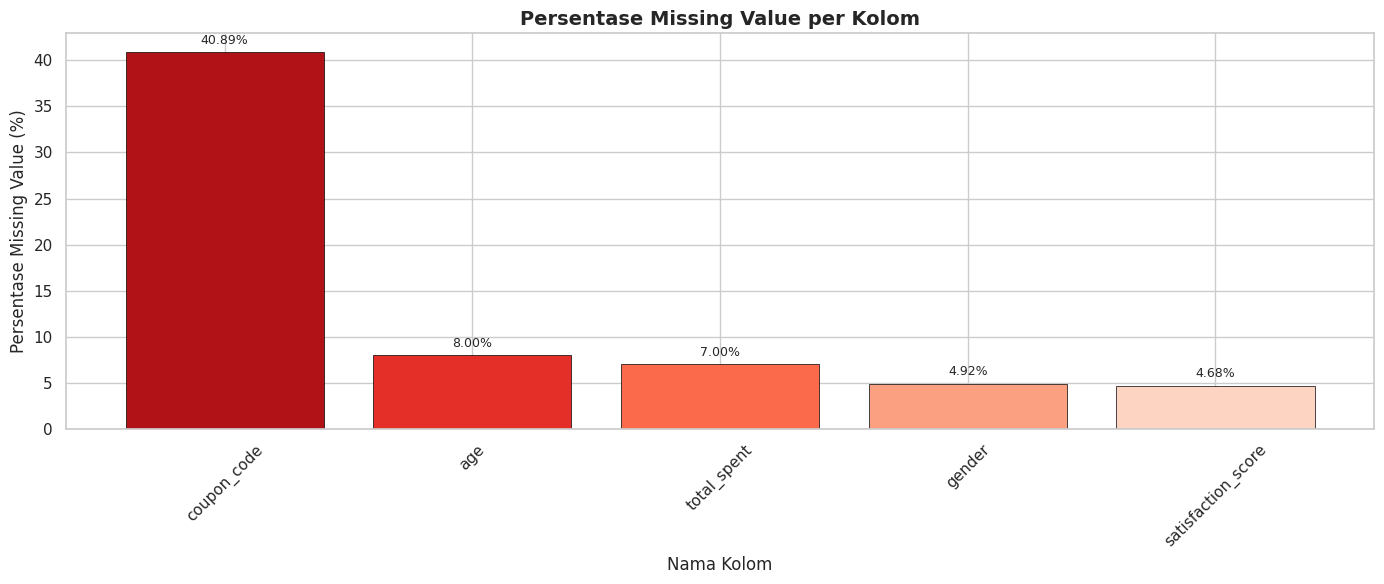

Plot disimpan sebagai missing_value_chart.png


In [10]:
# Visualisasi: Diagram Batang Missing Value
cols_with_missing = missing_df[missing_df['Persentase (%)'] > 0]

if cols_with_missing.empty:
    print('Tidak ada missing value pada dataset ini!')
    # Tetap tampilkan chart dengan nilai 0 untuk semua kolom
    plot_data = missing_df
else:
    plot_data = cols_with_missing

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    plot_data.index,
    plot_data['Persentase (%)'],
    color=sns.color_palette('Reds_r', len(plot_data)),
    edgecolor='black',
    linewidth=0.5
)

# Tambahkan label nilai di atas bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f'{height:.2f}%',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4), textcoords='offset points',
        ha='center', va='bottom', fontsize=9
    )

ax.set_title('Persentase Missing Value per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Nama Kolom', fontsize=12)
ax.set_ylabel('Persentase Missing Value (%)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('missing_value_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai missing_value_chart.png')

###Distribusi Label

In [11]:
# Hitung distribusi churn
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

churn_summary = pd.DataFrame({
    'Label'       : ['Tidak Churn (0)', 'Churn (1)'],
    'Jumlah'      : [churn_counts[0], churn_counts[1]],
    'Persentase (%)': [churn_pct[0].round(2), churn_pct[1].round(2)]
})

print('Distribusi Variabel Target: Churn')
print(churn_summary.to_string(index=False))

Distribusi Variabel Target: Churn
          Label  Jumlah  Persentase (%)
Tidak Churn (0)   12702           84.68
      Churn (1)    2298           15.32


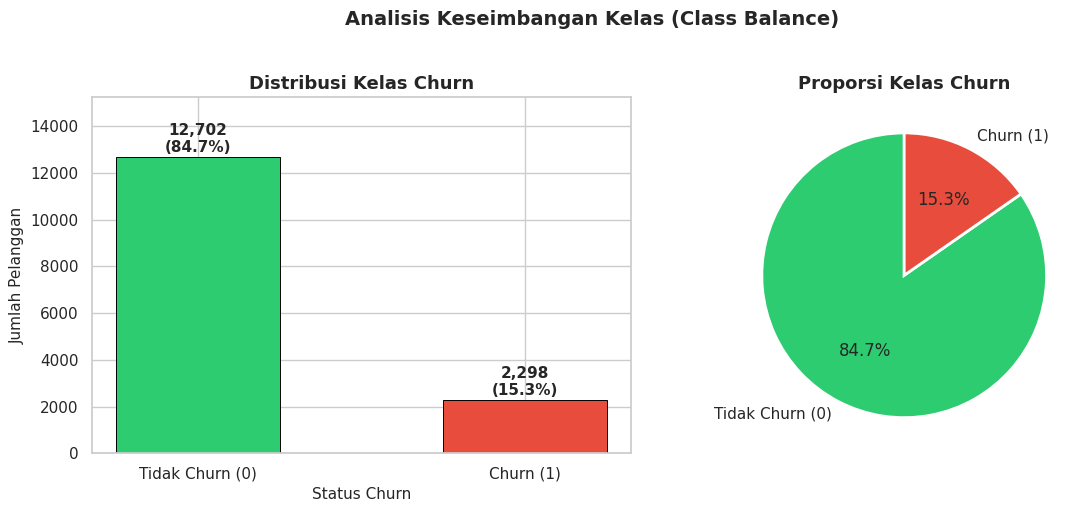

Plot disimpan sebagai churn_distribution.png


In [12]:
# Visualisasi: Diagram Batang Distribusi Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Diagram Batang ---
labels = ['Tidak Churn (0)', 'Churn (1)']
values = [churn_counts[0], churn_counts[1]]
colors = ['#2ecc71', '#e74c3c']

bars = axes[0].bar(labels, values, color=colors, edgecolor='black', linewidth=0.7, width=0.5)

for bar, val, pct in zip(bars, values, [churn_pct[0], churn_pct[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{val:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

axes[0].set_title('Distribusi Kelas Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status Churn', fontsize=11)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
axes[0].set_ylim(0, max(values) * 1.2)

# --- Pie Chart (pelengkap) ---
axes[1].pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Kelas Churn', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Keseimbangan Kelas (Class Balance)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai churn_distribution.png')


###Heatmap Korelasi Fitur Numerik

In [14]:
# Pilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Kolom numerik ({len(numeric_cols)}): {numeric_cols}')

Kolom numerik (20): ['customer_id', 'age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


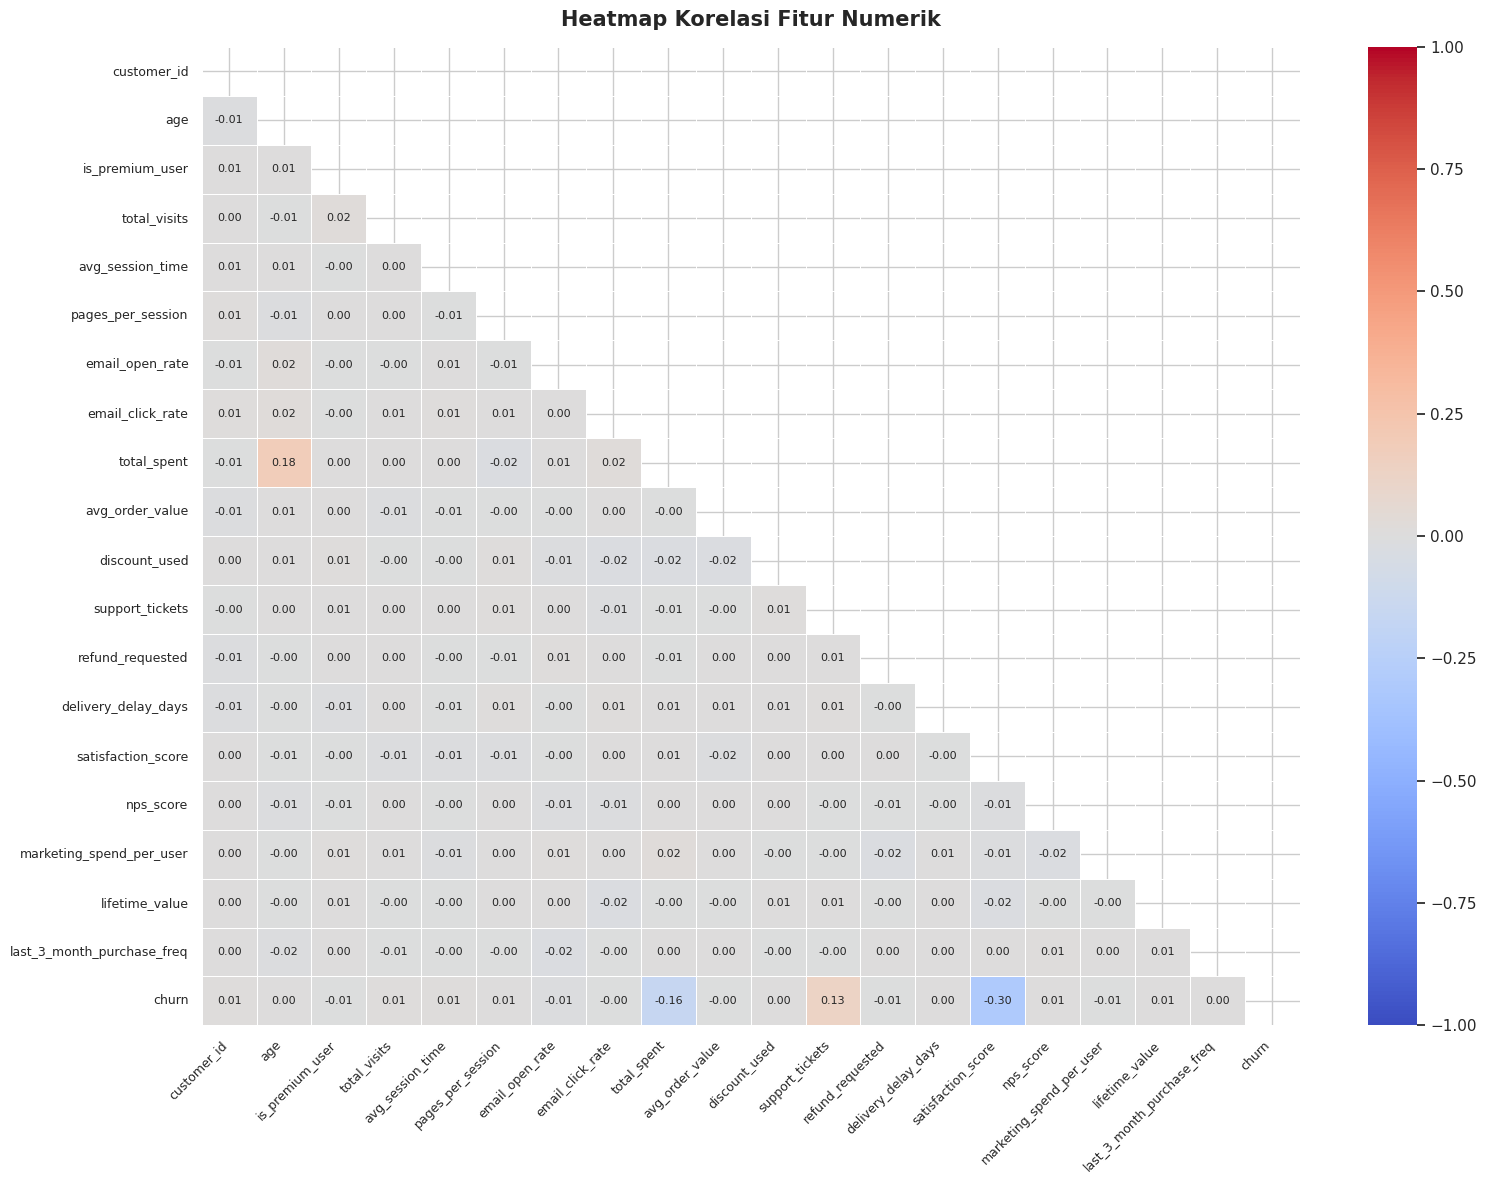

Plot disimpan sebagai correlation_heatmap.png


In [15]:
# Hitung matriks korelasi
corr_matrix = df[numeric_cols].corr()

# Heatmap Korelasi
fig, ax = plt.subplots(figsize=(16, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Sembunyikan segitiga atas agar lebih bersih

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai correlation_heatmap.png')

Korelasi Fitur Terhadap Target Churn (Diurutkan)
satisfaction_score           -0.3036
total_spent                  -0.1633
support_tickets               0.1279
total_visits                  0.0132
customer_id                   0.0122
avg_session_time              0.0122
email_open_rate              -0.0084
marketing_spend_per_user     -0.0073
refund_requested             -0.0070
lifetime_value                0.0063
pages_per_session             0.0059
nps_score                     0.0057
is_premium_user              -0.0055
age                           0.0045
email_click_rate             -0.0018
delivery_delay_days           0.0016
last_3_month_purchase_freq    0.0016
avg_order_value              -0.0015
discount_used                 0.0003


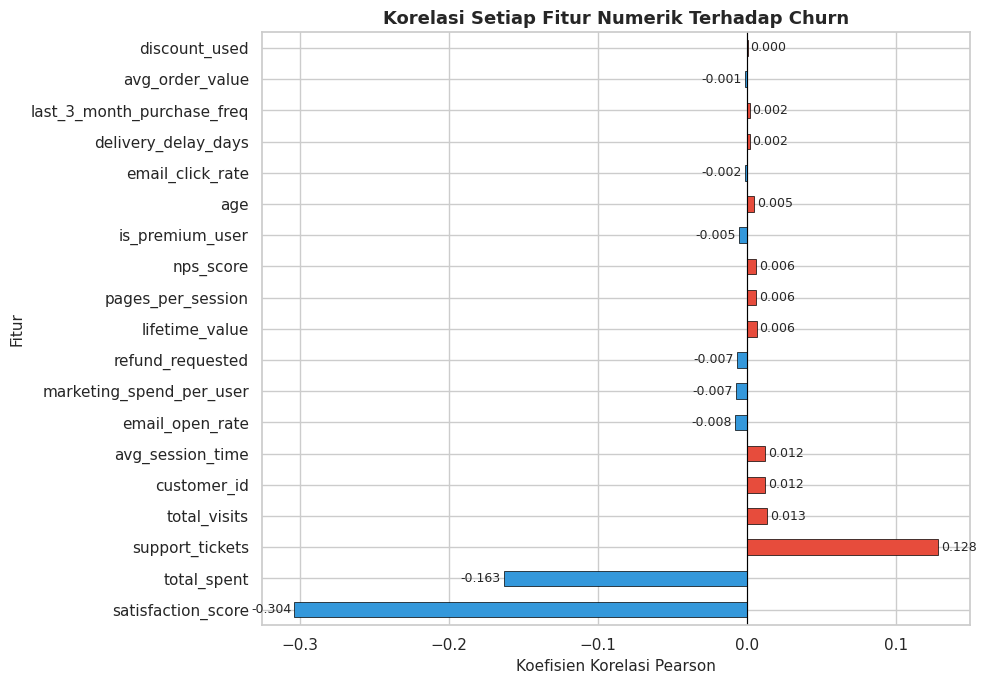

Plot disimpan sebagai churn_correlation_bar.png


In [16]:
# Identifikasi fitur yang paling berkorelasi dengan target 'churn'
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)

print('Korelasi Fitur Terhadap Target Churn (Diurutkan)')
print(churn_corr.round(4).to_string())

# Visualisasi Top Korelasi dengan Churn
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#e74c3c' if v > 0 else '#3498db' for v in churn_corr]
churn_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Setiap Fitur Numerik Terhadap Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)

# Tambahkan label nilai
for i, (val, label) in enumerate(zip(churn_corr, churn_corr.index)):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        i,
        f'{val:.3f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('churn_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan sebagai churn_correlation_bar.png')

In [17]:
# Identifikasi pasangan fitur dengan korelasi tinggi (multikolinearitas potensial)
print('Pasangan Fitur dengan Korelasi Tinggi (|r| > 0.7)')
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr_pairs.append({
                'Fitur 1': corr_matrix.columns[i],
                'Fitur 2': corr_matrix.columns[j],
                'Korelasi': round(val, 4)
            })

if high_corr_pairs:
    print(pd.DataFrame(high_corr_pairs).to_string(index=False))
else:
    print('Tidak ada pasangan fitur dengan korelasi > 0.7')

Pasangan Fitur dengan Korelasi Tinggi (|r| > 0.7)
Tidak ada pasangan fitur dengan korelasi > 0.7
